In [1]:
# Clustering Persistence Barcodes of Multidimensional Scaling Representations from Random Initial Configurations 
# Melinda A. Kleczynski, Anthony J. Kearsley

# Data from: https://cave.cs.columbia.edu/repository/COIL-100 
#            https://cave.cs.columbia.edu/repository/COIL-20 

# Versions at the time of writing 
# -------------------------------  
# Python                    3.13.2   
# matplotlib                3.10.1
# numpy                     2.2.4
# oat_python                0.1.1
# scikit-learn              1.7.0
# scipy                     1.15.2 

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import numpy as np 

import oat_python as oat

from PIL import Image

import random 

from scipy.optimize import least_squares 
from scipy.sparse import csr_matrix 
from scipy.spatial.distance import pdist, squareform  

from sklearn.cluster import DBSCAN 
from sklearn.manifold import MDS 
from sklearn.mixture import GaussianMixture

### Select dataset and optimization algorithm

In [3]:
algorithm = 'SMACOF'  # 'SMACOF' or 'Least-Squares'
example = 1  # 1 or 2 

if example == 1:

    short_example_name = 'Tomato' 
    dataset_folder = 'coil-100'
    object_number = 4
    metric = 'euclidean'

elif example == 2:

    short_example_name = 'Duck'
    dataset_folder = 'coil-20-proc'
    object_number = 1  
    metric = 'euclidean' 

example_name = algorithm + ' ' + short_example_name

### Read and process data

In [4]:
def read_image(dataset_folder, object_number, image_index):

    fpath = dataset_folder + '\\obj' + str(object_number) + '__'

    if dataset_folder == 'coil-100':
        fpath += str(5*image_index)
    elif dataset_folder == 'coil-20-proc':
        fpath += str(image_index)

    fpath += '.png'
    
    image = np.asarray(Image.open(fpath))
    return image/np.max(image) 

In [5]:
n_images = 72

In [6]:
# images ordered by ground truth angle; shuffle to hide ground truth 

shuffled_image_indices = [i for i in range(n_images)] 
random.seed(0) 
random.shuffle(shuffled_image_indices) 

In [7]:
images = [read_image(dataset_folder, object_number, index) for index in shuffled_image_indices] 
unscaled_image_data = np.vstack([image.flatten() for image in images]) 
unscaled_image_pdist = squareform(pdist(unscaled_image_data, metric = metric)) 

scale_by = (2/np.sum(np.square(unscaled_image_pdist)))**0.5
image_pdist = scale_by*unscaled_image_pdist

### Functions

In [8]:
# random initializations

m = n_images*(n_images-1)/2 
S = np.sum(np.square(image_pdist))/2  
sigma = (S/(4*m))**0.5

def get_random_init(algorithm, seed = None):

    if algorithm == 'SMACOF':
        size = (n_images, 2)  
    elif algorithm == 'Least-Squares':
        size = 2*n_images-3  # x and y coordinate for each object, one object at origin, one object on x-axis

    rng = np.random.default_rng(seed = seed)  
    return sigma*rng.normal(size = size) 

In [9]:
# least-squares optimization functions 

def vec_to_coords(vec):
    coords = np.zeros((n_images, 2)) 
    coords[1, 0] = vec[0] 
    coords[2:, :] = vec[1:].reshape((n_images-2, 2))
    return coords

def f(v, Delta, n): 

    X = vec_to_coords(v)
    X_pdist = squareform(pdist(X, metric = 'euclidean')) 
    rs = X_pdist - Delta

    return [rs[i, j] for j in range(n) for i in range(j)] 

In [10]:
# topological data analysis functions 

def get_ph1_pc(pt_cloud):  # input: npoints x dim 

    maxrad = oat.dissimilarity.enclosing_from_cloud(pt_cloud) + 0.001 
    dissimilairty_matrix = oat.dissimilarity.matrix_from_cloud(cloud = pt_cloud, dissimilarity_max = maxrad)
    boundary = oat.rust.FactoredBoundaryMatrixVr(dissimilarity_matrix = dissimilairty_matrix, homology_dimension_max = 1)
    ph = boundary.homology(return_cycle_representatives = False, return_bounding_chains = False)  
    ph1 = ph[ph.dimension == 1] 
    ph1.insert(4, 'persistence', ph1.death-ph1.birth)  

    return ph1 

def get_ph1_distmat(distance_matrix):  # input: npoints x npoints 

    # format pairwise distance matrix 
    n_data_pts = np.shape(distance_matrix)[0]  
    formatted_dist_mat = csr_matrix(distance_matrix)
    for i in range(n_data_pts):
        for j in range(n_data_pts):
            if distance_matrix[i, j] == 0:
                formatted_dist_mat[i, j] = 0  # need explicit zeros

    # perform TDA    
    boundary = oat.rust.FactoredBoundaryMatrixVr(dissimilarity_matrix = formatted_dist_mat, homology_dimension_max = 1)   
    ph = boundary.homology(return_cycle_representatives = False, return_bounding_chains = False)   
    ph1 = ph[ph.dimension == 1] 
    ph1.insert(4, 'persistence', ph1.death-ph1.birth)  

    return ph1

### Obtain and quantify many MDS representations 

In [11]:
n_trials = 10000

stresses = np.zeros(n_trials)  
iters = np.zeros(n_trials, int)

max_persist = np.zeros(n_trials) 
other_persist = np.zeros(n_trials)

for t in range(n_trials):

    # mds 
    random_init = get_random_init(algorithm, t)   
    if algorithm == 'SMACOF':
        mds_alg = MDS(n_components = 2, 
                      dissimilarity = 'precomputed', 
                      n_init = 1, 
                      max_iter = 5000, 
                      eps = 1e-8)
        mds_xy = mds_alg.fit_transform(image_pdist, init = random_init)
        iters[t] = mds_alg.n_iter_
    elif algorithm == 'Least-Squares':
        mds_vec = least_squares(f, random_init, args = [image_pdist, n_images], method = 'lm').x  
        mds_xy = vec_to_coords(mds_vec)

    # stress 
    mds_pdist = squareform(pdist(mds_xy, metric = 'euclidean'))
    stresses[t] = np.sum(np.square(mds_pdist - image_pdist))/2  

    # tda
    mds_ph1 = get_ph1_pc(mds_xy)  

    if len(mds_ph1) == 0:
        max_persist[t] = 0
        other_persist[t] = 0
    else:
        mp = np.max(mds_ph1.persistence)
        max_persist[t] = mp
        other_persist[t] = np.sum(mds_ph1.persistence) - mp 

### Clustering

In [12]:
combined_features = np.transpose(np.vstack([max_persist, other_persist]))
feature_names = ['$c_1$: Maximum Bar Length', '$c_2$: Sum of Remaining Bar Lengths']

In [13]:
# get cluster labels

if example == 1:

    GM_probs = GaussianMixture(n_components = 2, tol = 1e-8, random_state = 0).fit(combined_features).predict_proba(combined_features)
    clabels = np.zeros(n_trials, int)
    for t in range(n_trials):
        this_trial_probs = GM_probs[t, :]
        if np.max(this_trial_probs) < 0.8: 
            clabels[t] = 0 
        else:
            clabels[t] = 1+np.argmax(this_trial_probs)

elif example == 2: 
    
    DBSCAN_eps = 0.001 
    DBSCAN_min_samples = int(0.005*n_trials)
    clabels = DBSCAN(eps = DBSCAN_eps, min_samples = DBSCAN_min_samples).fit(combined_features).labels_ + 1

n_clusters = np.max(clabels)  # number of clusters, not counting DBSCAN noise points 

# reorder cluster labels (exclusing noise) by cluster size
non_noise_cluster_sizes = np.array([np.sum(clabels == c) for c in range(1, n_clusters+1)])
old_labels = np.array([c for c in range(1, n_clusters+1)])[np.argsort(-non_noise_cluster_sizes)]
new_labels = np.array([c for c in range(1, n_clusters+1)])
relabeling = dict(zip(old_labels, new_labels))
relabeling[0] = 0
clabels = np.array([relabeling[cl] for cl in clabels])

In [14]:
# find the configuration in each cluster which has the lowest stress 

lowest_stress_configs = [-1] * n_clusters

for c in range(1, n_clusters+1):

    cluster_members = [t for t in range(n_trials) if clabels[t] == c]
    cluster_stresses = stresses[cluster_members]
    lowest_stress_configs[c-1] = cluster_members[np.argmin(cluster_stresses)]

### Plots

In [15]:
# choose appearance for different clusters (first is for DBSCAN noise points)
colors = ['silver'] + 3*[(0, 0, 0, 0)]
edgecolors = [None, (115/255, 184/255, 231/255), 'tab:orange', (96/255, 210/255, 96/255)]  
barcodecolors = [None, (42/255, 147/255, 218/255), (246/255, 117/255, 0/255), (52/255, 186/255, 52/255)]  # slightly darker for barcodes
markers = ['x', 's', 'o', 'd']
labels = ['Noise'] + ['Cluster ' + str(c) for c in range(1, n_clusters+1)]

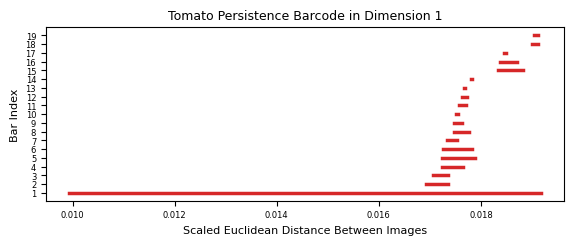

In [16]:
# plot barcode of original dataset 

orig_ph1 = get_ph1_distmat(image_pdist)
orig_sorted_bc1 = orig_ph1.sort_values(by = 'birth', ignore_index = True)[['birth', 'death']]
orig_nbars = len(orig_sorted_bc1)

if example == 1:
    bar_color = 'tab:red' 
elif example == 2:
    bar_color = 'goldenrod'

fig, ax = plt.subplots(figsize = (6.69, 2.25))
for bar_iter in range(orig_nbars):
    ax.plot(orig_sorted_bc1.iloc[bar_iter], [bar_iter+1, bar_iter+1], color = bar_color, lw = 2.5)
ax.set_title(short_example_name + ' Persistence Barcode in Dimension 1', fontsize = 9)
ax.set_xlabel('Scaled Euclidean Distance Between Images', fontsize = 8)
ax.set_ylabel('Bar Index', fontsize = 8)
ax.set_yticks([i for i in range(1, orig_nbars+1)])
ax.tick_params(labelsize = 6)

plt.show()

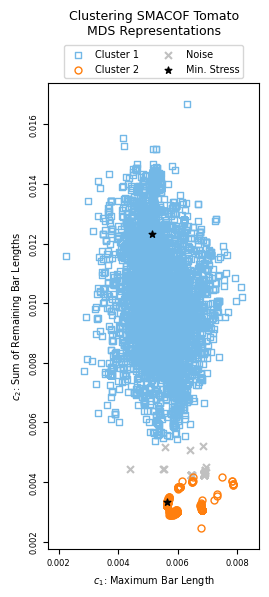

In [17]:
fig, ax = plt.subplots(figsize = (3.0, 6.05)) 

for c in [c for c in range(1, n_clusters+1)] + [0]:
    ax.scatter(combined_features[clabels == c, 0], combined_features[clabels == c, 1], 
               color = colors[c], edgecolors = edgecolors[c], marker = markers[c], s = 25, label = labels[c], zorder = c)

low_label = 'Min. Stress'
for c in range(1, n_clusters+1):
    ax.scatter(combined_features[lowest_stress_configs[c-1], 0], combined_features[lowest_stress_configs[c-1], 1], 
                marker = '*', color = 'k', s = 25, label = low_label, zorder = n_clusters+1)
    low_label = ''

ax.set_aspect('equal')
ax.legend(prop = {'size': 7}, loc = 'lower center', bbox_to_anchor = (0.5, 1.0), ncol = 2)
ax.tick_params(labelsize = 6) 
plt.yticks(rotation = 90, va = 'center')
ax.xaxis.set_major_locator(ticker.MultipleLocator(base = 0.002))
ax.yaxis.set_major_locator(ticker.MultipleLocator(base = 0.002))
ax.set_xlabel(feature_names[0], fontsize = 7)
ax.set_ylabel(feature_names[1], fontsize = 7)

if example == 1:
    title_pad = 35 
    ax.margins(x = 0.1, y = 0.05)
elif example == 2:
    title_pad = 45
    ax.margins(x = 0.05, y = 0.1)
ax.set_title('Clustering ' + example_name + '\nMDS Representations', fontsize = 9, pad = title_pad)

plt.show()

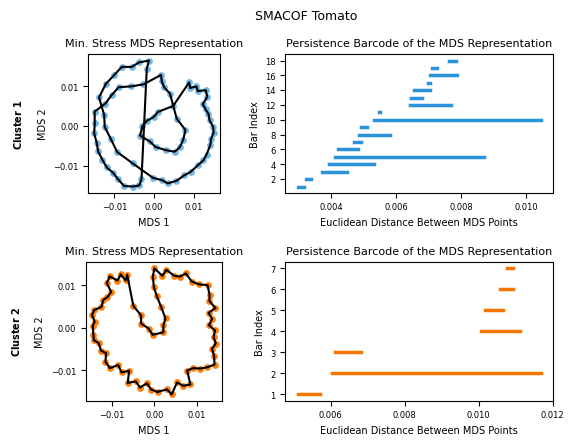

In [18]:
ground_truth = np.hstack([np.argsort(shuffled_image_indices), [np.argmin(shuffled_image_indices)]])  # used for plotting line segments

if example == 1:
    ht_per_cluster = 2.25 
    title_y = 0.98
elif example == 2:
    ht_per_cluster = 2.25
    title_y = 0.96

fig, ax = plt.subplots(n_clusters, 2, figsize = (6.16, ht_per_cluster*n_clusters), width_ratios = [0.37, 0.63])

for c in range(1, n_clusters + 1):
        
    t = lowest_stress_configs[c-1]

    # mds 
    random_init = get_random_init(algorithm, t)
    if algorithm == 'SMACOF':
        mds_alg = MDS(n_components = 2, 
                      dissimilarity = 'precomputed', 
                      n_init = 1, 
                      max_iter = 5000, 
                      eps = 1e-8) 
        mds_xy = mds_alg.fit_transform(image_pdist, init = random_init)
    elif algorithm == 'Least-Squares':
        mds_vec = least_squares(f, random_init, args = [image_pdist, n_images], method = 'lm').x  
        mds_xy = vec_to_coords(mds_vec)

    # tda
    mds_ph1 = get_ph1_pc(mds_xy)  

    # plot mds representation
    ax[c-1, 0].scatter(mds_xy[:, 0], mds_xy[:, 1], s = 15, color = edgecolors[c])
    ax[c-1, 0].plot(mds_xy[ground_truth, 0], mds_xy[ground_truth, 1], color = 'k')
    ax[c-1, 0].set_aspect('equal') 
    ax[c-1, 0].set_title('Min. Stress MDS Representation', fontsize = 8)
    ax[c-1, 0].set_xlabel('MDS 1', fontsize = 7)
    ax[c-1, 0].set_ylabel(r'$\mathbf{Cluster\ ' + str(c) + '}$\n\n' + 'MDS 2', fontsize = 7)
    ax[c-1, 0].tick_params(labelsize = 6)
    ax[c-1, 0].xaxis.set_major_locator(ticker.MultipleLocator(base = 0.01))
    ax[c-1, 0].yaxis.set_major_locator(ticker.MultipleLocator(base = 0.01))

    # plot barcode
    sorted_bc1 = mds_ph1.sort_values(by = 'birth', ignore_index = True)[['birth', 'death']]
    nbars = len(sorted_bc1)
    for bar_iter in range(nbars):
        ax[c-1, 1].plot(sorted_bc1.iloc[bar_iter], [bar_iter+1, bar_iter+1], color = barcodecolors[c], lw = 2.5)
    ax[c-1, 1].set_title('Persistence Barcode of the MDS Representation', fontsize = 8)
    ax[c-1, 1].set_xlabel('Euclidean Distance Between MDS Points', fontsize = 7)
    ax[c-1, 1].set_ylabel('Bar Index', fontsize = 7)
    ax[c-1, 1].tick_params(labelsize = 6)
    ax[c-1, 1].xaxis.set_major_locator(ticker.MultipleLocator(base = 0.002))
    if nbars < 10:
        ax[c-1, 1].yaxis.set_major_locator(ticker.MultipleLocator(base = 1))
        if nbars < 5:
            ax[c-1, 1].set_ymargin(0.4)
    else:
        ax[c-1, 1].yaxis.set_major_locator(ticker.MultipleLocator(base = 2))

plt.subplots_adjust(hspace = 0.5, wspace = 0.25)
plt.suptitle(example_name, fontsize = 9, y = title_y)
plt.savefig('min_stress_in_cluster' + str(example) + algorithm + '.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()